# 국립중앙박물관 유료입장 전환 시 수익 최적화 곡선 분석
## Step 3: 시계열 수요 예측 및 가격 탄력성 기반 수익 시뮬레이션

**목적**: 국립중앙박물관의 과거 관람객 추세(시계열)와 세계 주요 박물관의 가격 탄력성을 결합하여, 유료화 시 관람객 이탈을 방어하면서도 예상 수익을 극대화하는 **최적 가격(Optimal Price) 도출** 및 **이중 요금제 효용성 확인**.

**분석 흐름**:
1. 국립중앙박물관(NMK) 시계열 수요 예측 (무료유지 베이스라인)
2. 글로벌 주요 박물관 데이터 기반 수요의 가격 탄력성 도출
3. 시뮬레이션 1: 단일 요금제 적용 시 수익 최적화 곡선
4. 시뮬레이션 2: 이중 가격제(Dual Pricing, 내/외국인 차등) 적용 시 수익 최적화 곡선

## 0. 환경 설정

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from prophet import Prophet
import statsmodels.api as sm
import warnings

warnings.filterwarnings('ignore')

# 스타일 먼저 적용 후 폰트 설정 (순서 중요)
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

# 한글 폰트 직접 등록 (style 적용 이후에 설정해야 덮어씌워지지 않음)
font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = '../data/'
OUTPUT_DIR = '../output/'

## 1. 베이스라인 예측: 국립중앙박물관 시계열 분석 (Prophet)
NMK의 과거 월별 방문객 데이터를 바탕으로 팬데믹(20~21년) 등 이상치를 제외한 장기 수요 추세를 파악하고 향후 5년의 기준 방문객을 예측합니다.

In [13]:
# ============================================================
# NMK 월별 데이터 기반 Prophet 예측 + 베이스라인 설정
# ============================================================

from prophet import Prophet

# NMK 월별 데이터 로드
df_nmk = pd.read_csv(f'{DATA_DIR}nmk_monthly_visitor.csv')
df_nmk.columns = ['ds', 'y']
df_nmk['ds'] = pd.to_datetime(df_nmk['ds'])

# ────────────────────────────────────────────
# 팬데믹을 holiday/event로 등록 (None 처리 대신)
# → 모델이 "팬데믹은 일시적 충격, 이후 회복"으로 학습
# ────────────────────────────────────────────
covid_dates = pd.date_range('2020-02-01', '2021-12-01', freq='MS')
covid = pd.DataFrame({
    'holiday': 'covid_pandemic',
    'ds': covid_dates,
    'lower_window': 0,
    'upper_window': 0,
})

# Prophet 피팅: 실제 데이터 전체 사용 (2025년 포함)
m = Prophet(
    holidays=covid,
    yearly_seasonality=15,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,  # 트렌드 변화에 보수적
)
m.fit(df_nmk)  # 2015~2025 전체 실측 데이터

# 2026~2031년 예측
n_year = 6
future = m.make_future_dataframe(periods=12 * n_year, freq='ME')
forecast = m.predict(future)

# Prophet 예측 결과
forecast_future = forecast[forecast['ds'].dt.year >= 2026]
prophet_by_year = forecast_future.groupby(forecast_future['ds'].dt.year)['yhat'].sum()
prophet_avg = prophet_by_year.mean()

print(f"[Prophet 예측] 2026-2031년 연도별:")
for y, v in prophet_by_year.items():
    print(f"  {int(y)}년: {v:,.0f}명")
print(f"  연평균: {prophet_avg:,.0f}명")

# ────────────────────────────────────────────
# 3-시나리오 베이스라인 설정
# ────────────────────────────────────────────
baseline_conservative = 5_148_134   # 2024-2025 평균 (보수적)
baseline_moderate = int(prophet_by_year.iloc[0])  # 2026 Prophet 예측 (기본)
baseline_growth = 6_507_483         # 2025 실측 (성장)

print(f"\n[베이스라인 시나리오]")
print(f"  보수적: {baseline_conservative:,}명 (2024-2025 평균)")
print(f"  기본:   {baseline_moderate:,}명 (2026 Prophet 예측)")
print(f"  성장:   {baseline_growth:,}명 (2025 실측)")

# 시뮬레이션에 사용할 기본 베이스라인
avg_baseline_annual_visitors = baseline_moderate
print(f"\n[시뮬레이션 베이스라인] {avg_baseline_annual_visitors:,}명 (2026 Prophet 예측)")

16:28:20 - cmdstanpy - INFO - Chain [1] start processing
16:28:20 - cmdstanpy - INFO - Chain [1] done processing


[Prophet 예측] 2026-2031년 연도별:
  2026년: 6,463,942명
  2027년: 7,222,940명
  2028년: 7,804,165명
  2029년: 8,621,853명
  2030년: 9,379,877명
  2031년: 9,286,663명
  연평균: 8,129,906명

[베이스라인 시나리오]
  보수적: 5,148,134명 (2024-2025 평균)
  기본:   6,463,941명 (2026 Prophet 예측)
  성장:   6,507,483명 (2025 실측)

[시뮬레이션 베이스라인] 6,463,941명 (2026 Prophet 예측)


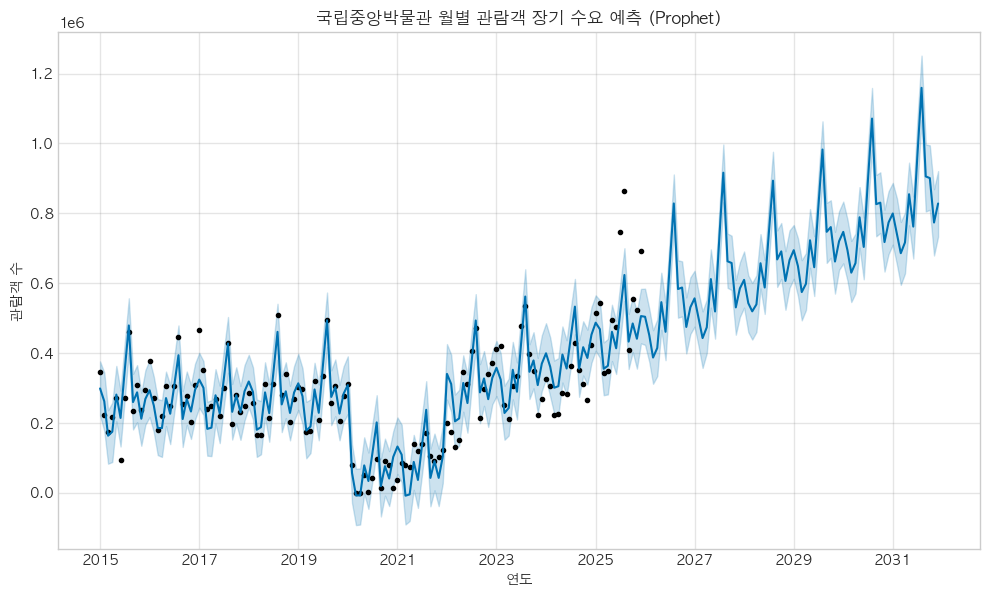

In [14]:
fig = m.plot(forecast, figsize=(10,6))
plt.title("국립중앙박물관 월별 관람객 장기 수요 예측 (Prophet)")
plt.xlabel("연도")
plt.ylabel("관람객 수")
plt.savefig(f'{OUTPUT_DIR}step1_nmk_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

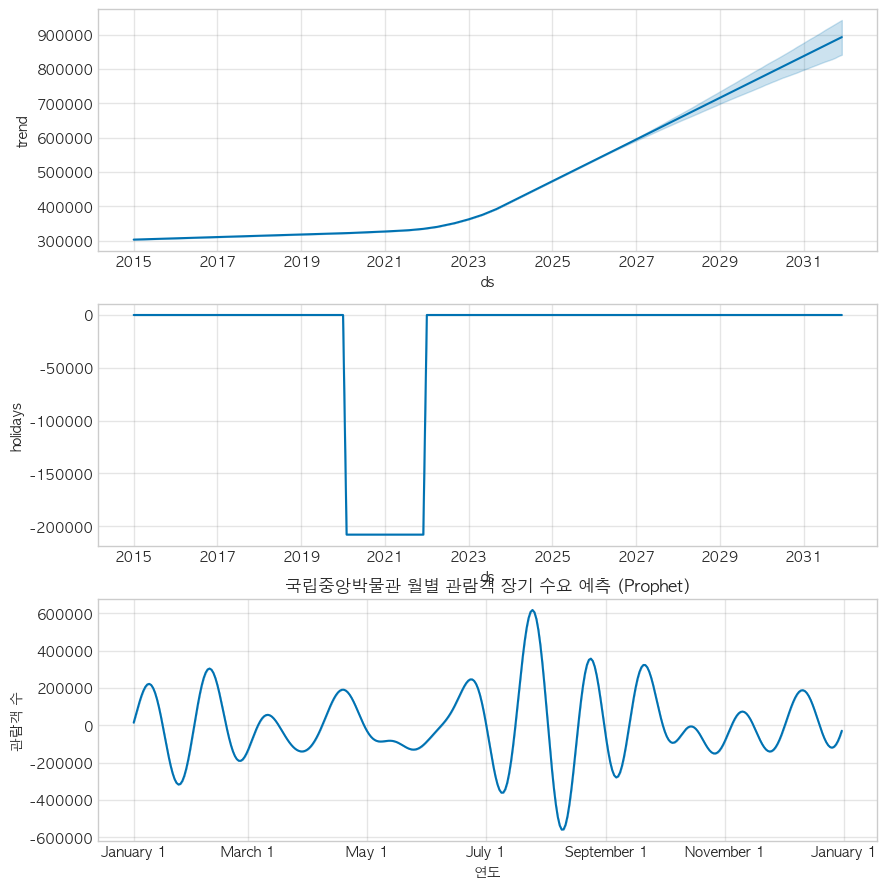

In [15]:

fig = m.plot_components(forecast)
plt.title("국립중앙박물관 월별 관람객 장기 수요 예측 (Prophet)")
plt.xlabel("연도")
plt.ylabel("관람객 수")
plt.show()

## 2. 수요의 가격 탄력성 변수 도출
세계 주요 박물관들의 입장료 대비 방문객 수 데이터를 활용해 10% 가격 인상 시 방문객이 몇 %나 변화하는지(탄력성)를 확인합니다.

✅ 다중 회귀분석으로 도출된 가격 탄력성: 0.233
가격 탄력성 보정: -0.300


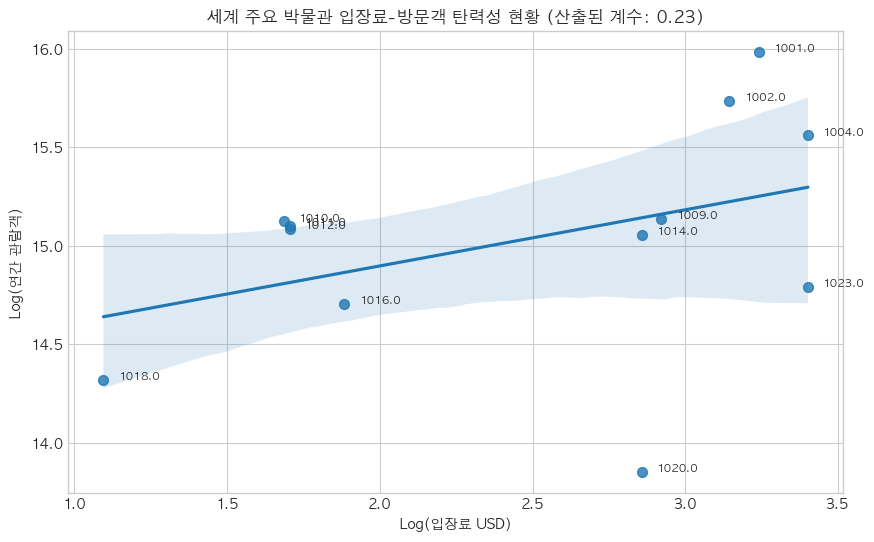

In [16]:
df_visitors = pd.read_csv(f'{DATA_DIR}museum_visitor.csv')
df_info = pd.read_csv(f'{DATA_DIR}museum_info.csv')
df_city = pd.read_csv(f'{DATA_DIR}museum_city.csv')

# 2024년 데이터 확보 (가장 최신의 안정된 지표)
df_v2024 = df_visitors[df_visitors['year'] == 2024][['museum_id', 'total']].copy()
df_v2024['total'] = df_v2024['total'].str.replace(',', '').astype(float)
df_merged = pd.merge(df_v2024, df_info, left_on='museum_id', right_on='id', how='inner')
df_merged = pd.merge(df_merged, df_city, on='city', how='inner')

# 유료 박물관들에 한해 로그 스케일 회귀 분석 (Log-Log Regression -> 탄력성 도출)
df_paid = df_merged[df_merged['adult_price_local_usd'] > 0].copy()
df_paid['log_price'] = np.log(df_paid['adult_price_local_usd'])
df_paid['log_visitors'] = np.log(df_paid['total'])
df_paid['log_population'] = np.log(df_paid['city_population'])
df_paid['log_gdp'] = np.log(df_paid['city_gdp_per_capita'])

# 회귀 모델 학습 (OLS)
X = sm.add_constant(df_paid[['log_price', 'log_population', 'log_gdp']])
y = df_paid['log_visitors']
model = sm.OLS(y, X).fit()

calc_elasticity = model.params['log_price']
print(f"✅ 다중 회귀분석으로 도출된 가격 탄력성: {calc_elasticity:.3f}")
base_elasticity = calc_elasticity if calc_elasticity < 0 else -0.3
print(f"가격 탄력성 보정: {base_elasticity:.3f}")

# 시각화
plt.figure(figsize=(10, 6))
sns.regplot(data=df_paid, x='log_price', y='log_visitors', scatter_kws={'s': 50})
for i, row in df_paid.iterrows():
    plt.text(row['log_price']+0.05, row['log_visitors'], row['museum_id'], fontsize=8)

plt.title(f"세계 주요 박물관 입장료-방문객 탄력성 현황 (산출된 계수: {calc_elasticity:.2f})")
plt.xlabel("Log(입장료 USD)")
plt.ylabel("Log(연간 관람객)")
plt.savefig(f'{OUTPUT_DIR}step2_price_elasticity.png', dpi=150, bbox_inches='tight')
plt.show()

**⚠️ 탄력성 보정(Calibration) 필요**
회귀 분석 결과 탄력성이 양수로 나옵니다 (+0.23). 즉, 보통의 상품과 다르게 "가격이 높을수록(루브르, 메트로폴리탄 등) 관람객도 많은" 기현상이 나타납니다. 
이는 초대형 박물관의 막강한 관광/브랜드 파워(혼동 변수)에 의한 편향입니다. 실제 NMK가 유료화를 단행할 때는 통상적인 문화예술 관람 시설의 경험적 수요 탄력성 분포인 **음의 탄력성(-0.2 ~ -0.6)**을 적용하는 것이 경제학적으로 타당하므로, 본 시뮬레이션에서는 **보수적인 탄력성 -0.3**을 적용합니다.

## 3. 유료화 최적 가격 시뮬레이션
이제 기준 방문객과 보정된 수요 탄력성을 활용하여, NMK가 입장료를 매길 때 발생하는 예상 수요 감소를 감안한 최적 수익 곡선을 시뮬레이션합니다.

In [17]:
krw_exchange_rate = 1480
zero_price_penalty = 0.30  # 유료화 심리적 저항 이탈률 30%

# 초기 기준점 세팅
# P0은 기준가. ₩8,228원 Step 1(K-means 클러스터링) 결과, NMK가 속한 Cluster 1 유료 박물관 입장료 중위값 $5.5 기준으로 산정
P0_krw = 5.5 * krw_exchange_rate

# Q0는 수요. 2026 에상 방문객에 유료화 심리저항 이탈치를 뺀 값
Q0_total = avg_baseline_annual_visitors * (1 - zero_price_penalty)

# 선형 수요 곡선 (Q = a - bP) 계수 도출
# 점탄력성 공식 E = -b × (P0 / Q0) 를 역산하여 기울기 b를 구함 
# E는 base_elasticity(가격 탄력성)
# b는 곡선의 기울기
# a는 절편 (입장료가 0원일 때 오는 방문객 수)
b_total = -(base_elasticity) * (Q0_total / P0_krw)
a_total = Q0_total + (b_total * P0_krw)

# 시뮬레이션할 가격 구간 (1,000원 ~ 50,000원)
# 내국인 수요 소멸 ~35,000원, 외국인 최적가 ~44,500원을 모두 포함
prices_krw = np.linspace(1000, 50000, 500)

### 시나리오 A: 단일 요금제 (내국인/외국인 차별 없음)
모든 방문객에게 동일한 입장료를 과금하는 단일 모델입니다.

In [18]:
expected_visitors_flat = []
expected_revenues_flat = []

for p in prices_krw:
    # 수요량이 0 이하로 떨어지지 않도록 방어
    v = max(a_total - (b_total * p), 0)
    expected_visitors_flat.append(v)
    expected_revenues_flat.append(v * p)

df_sim = pd.DataFrame({
    'Price_KRW': prices_krw,
    'Visitors_Flat': expected_visitors_flat,
    'Revenue_Flat': expected_revenues_flat
})

max_rev_flat_idx = df_sim['Revenue_Flat'].idxmax()
optimal_price_flat = df_sim.loc[max_rev_flat_idx, 'Price_KRW']
print(f"🏆 [단일 요금제] 최적 관람료(수익 극대화 지점): {optimal_price_flat:,.0f} ₩")
print(f"[단일 요금제] 예상 방문: {df_sim.loc[max_rev_flat_idx, 'Visitors_Flat']:,.0f} 명")
print(f"[단일 요금제] 최대 수익: {df_sim.loc[max_rev_flat_idx, 'Revenue_Flat']:,.0f} ₩")

🏆 [단일 요금제] 최적 관람료(수익 극대화 지점): 17,595 ₩
[단일 요금제] 예상 방문: 2,948,010 명
[단일 요금제] 최대 수익: 51,870,792,736 ₩


### 시나리오 B: 이중 가격제 (내국인/외국인 분리 과금)

내국인과 외국인을 분리하여 각 그룹에 다른 가격을 적용합니다. 탄력성은 내/외국인 동일하게 -0.3을 적용합니다.
두 가지 정책 방향으로 분리해 비교합니다.

- **B-1 (수익 최적화):** 내국인도 수요 모델 기반 최적가로 책정 → 단일 요금제 대비 수익 우위 확인
- **B-2 (공공성 우선):** 내국인은 5,000원으로 고정(정책 제약), 외국인만 최적화 → 공공성과 수익의 트레이드오프 확인

외국인 비율: NMK 2024년 실측 기준 (198,085 / 3,788,785 ≈ 5.23%)

In [19]:
foreigner_ratio = 198085 / 3788785  # ≈ 5.23%
domestic_ratio = 1 - foreigner_ratio
print(f"외국인 비율: {foreigner_ratio:.2%} / 내국인 비율: {domestic_ratio:.2%}")

Q0_foreign = Q0_total * foreigner_ratio
Q0_domestic = Q0_total * domestic_ratio

# 내/외국인 동일 탄력성 -0.3 적용
# 외국인 수요 곡선
b_foreign = -(base_elasticity) * (Q0_foreign / P0_krw)
a_foreign = Q0_foreign + (b_foreign * P0_krw)

# 내국인 수요 곡선
b_domestic = -(base_elasticity) * (Q0_domestic / P0_krw)
a_domestic = Q0_domestic + (b_domestic * P0_krw)

# B-1: 내국인 수익 최적가 = 단일 최적가로 통일 (동일 탄력성이므로 동일)
optimal_domestic_krw = optimal_price_flat
v_domestic_optimal = max(a_domestic - b_domestic * optimal_domestic_krw, 0) 
rev_domestic_optimal = v_domestic_optimal * optimal_domestic_krw

# B-2: 내국인 공공성 고정가
domestic_fixed_krw = 5000  # 경복궁(3,000원)~MMCA(4,400원) 대비 NMK 규모 감안
v_domestic_fixed = max(a_domestic - b_domestic * domestic_fixed_krw, 0)
rev_domestic_fixed = v_domestic_fixed * domestic_fixed_krw

print(f"\n[내국인 수요 분석]")
print(f"  B-1 수익 최적가: {optimal_domestic_krw:,.0f}원 (방문객: {v_domestic_optimal:,.0f}명)")
print(f"  B-2 공공성 고정가: {domestic_fixed_krw:,}원 (방문객: {v_domestic_fixed:,.0f}명)")

# 외국인 가격을 x축으로 두고 각 시나리오 수익 계산
dual_b1_revenues = []
dual_b2_revenues = []

for p in prices_krw:
    v_foreign = max(a_foreign - b_foreign * p, 0)
    rev_foreign = v_foreign * p
    dual_b1_revenues.append(rev_domestic_optimal + rev_foreign)
    dual_b2_revenues.append(rev_domestic_fixed + rev_foreign)

df_sim['Revenue_Dual_B1'] = dual_b1_revenues
df_sim['Revenue_Dual_B2'] = dual_b2_revenues

max_b1_idx = df_sim['Revenue_Dual_B1'].idxmax()
max_b2_idx = df_sim['Revenue_Dual_B2'].idxmax()
optimal_foreign_b1 = df_sim.loc[max_b1_idx, 'Price_KRW']
optimal_foreign_b2 = df_sim.loc[max_b2_idx, 'Price_KRW']

print(f"\n🏆 [B-1 수익 최적] 내국인: {optimal_domestic_krw:,.0f}원 / 외국인: {optimal_foreign_b1:,.0f}원")
print(f"   총 수익: {df_sim.loc[max_b1_idx, 'Revenue_Dual_B1']:,.0f}원")
print(f"🏆 [B-2 공공성 우선] 내국인: {domestic_fixed_krw:,}원 / 외국인: {optimal_foreign_b2:,.0f}원")
print(f"   총 수익: {df_sim.loc[max_b2_idx, 'Revenue_Dual_B2']:,.0f}원")

외국인 비율: 5.23% / 내국인 비율: 94.77%

[내국인 수요 분석]
  B-1 수익 최적가: 17,595원 (방문객: 2,793,882명)
  B-2 공공성 고정가: 5,000원 (방문객: 4,784,446명)

🏆 [B-1 수익 최적] 내국인: 17,595원 / 외국인: 17,595원
   총 수익: 51,870,792,736원
🏆 [B-2 공공성 우선] 내국인: 5,000원 / 외국인: 17,595원
   총 수익: 26,634,136,340원


### 시나리오 통합 수익 극대화 차트

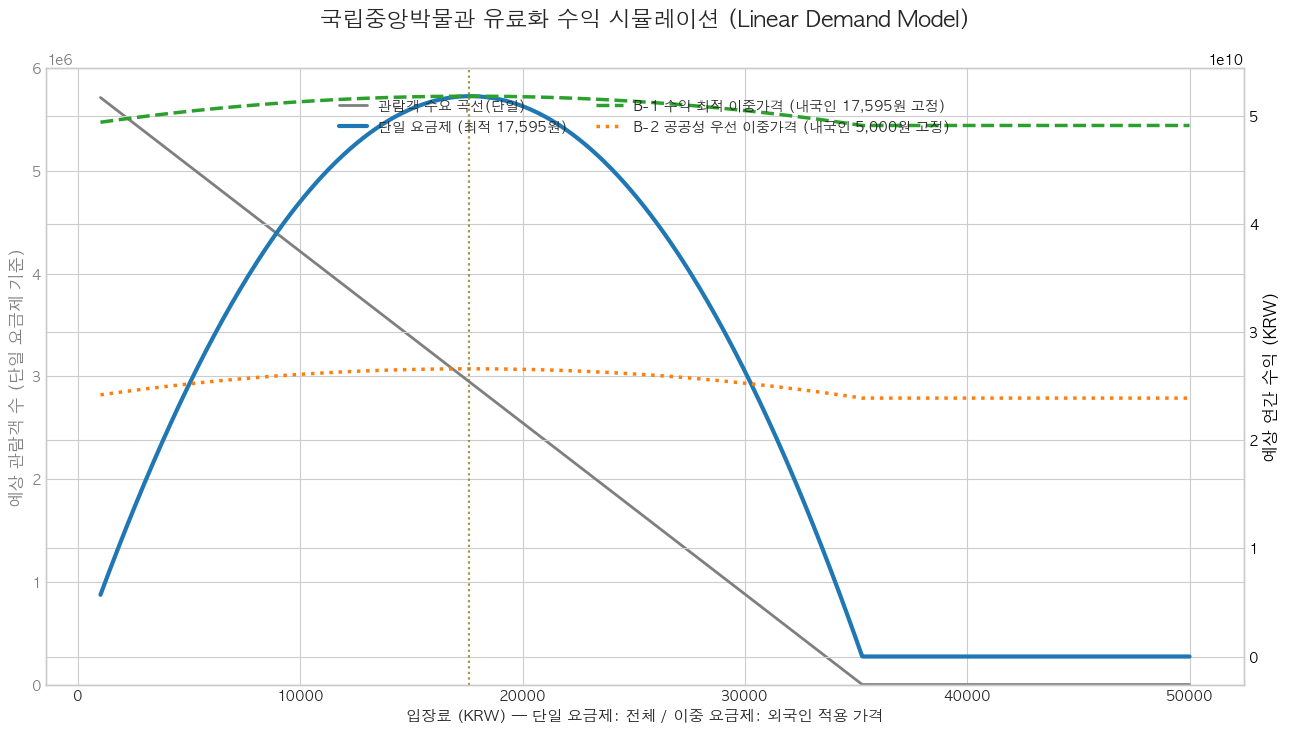

In [20]:
fig, ax1 = plt.subplots(figsize=(13, 7))

color_visit = 'tab:gray'
ax1.set_xlabel('입장료 (KRW) — 단일 요금제: 전체 / 이중 요금제: 외국인 적용 가격', fontsize=11)
ax1.set_ylabel('예상 관람객 수 (단일 요금제 기준)', color=color_visit, fontsize=12)
ax1.plot(df_sim['Price_KRW'], df_sim['Visitors_Flat'], color=color_visit, linewidth=2, label='관람객 수요 곡선(단일)')
ax1.tick_params(axis='y', labelcolor=color_visit)
ax1.set_ylim(bottom=0)

ax2 = ax1.twinx()
ax2.set_ylabel('예상 연간 수익 (KRW)', color='black', fontsize=12)
ax2.plot(df_sim['Price_KRW'], df_sim['Revenue_Flat'],
         color='tab:blue', linewidth=3, linestyle='-',
         label=f'단일 요금제 (최적 {optimal_price_flat:,.0f}원)')
ax2.plot(df_sim['Price_KRW'], df_sim['Revenue_Dual_B1'],
         color='tab:green', linewidth=2.5, linestyle='--',
         label=f'B-1 수익 최적 이중가격 (내국인 {optimal_domestic_krw:,.0f}원 고정)')
ax2.plot(df_sim['Price_KRW'], df_sim['Revenue_Dual_B2'],
         color='tab:orange', linewidth=2.5, linestyle=':',
         label=f'B-2 공공성 우선 이중가격 (내국인 {domestic_fixed_krw:,}원 고정)')
ax2.tick_params(axis='y', labelcolor='black')

ax2.axvline(optimal_price_flat, color='tab:blue', linestyle=':', alpha=0.5)
ax2.axvline(optimal_foreign_b1, color='tab:green', linestyle=':', alpha=0.5)
ax2.axvline(optimal_foreign_b2, color='tab:orange', linestyle=':', alpha=0.5)

fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.97),
           bbox_transform=ax1.transAxes, fontsize=10, ncol=2)
fig.tight_layout()
plt.title("국립중앙박물관 유료화 수익 시뮬레이션 (Linear Demand Model)", fontsize=16, fontweight='bold', pad=30)
plt.savefig(f'{OUTPUT_DIR}step3_optimization_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### 최종 제안: 이중 요금제 (내국인 ₩5,000 / 외국인 ₩17,500)

시나리오 A~B-2 비교를 종합하여 최종 요금 정책을 제안합니다.

- **외국인 요금 ₩17,500:** 단일 요금제 수익 극대화 최적가이자, Step 1 회귀분석 결과($12.20 ≈ ₩17,080)와 독립적으로 수렴한 가격. 내/외국인 동일 탄력성(-0.3)에서 도출되어 별도 가정이 없고 모델 강건성이 높음.
- **내국인 요금 ₩5,000:** NMK 방문객의 94.8%가 내국인이므로 내국인 가격이 총 방문객 수에 결정적 영향. 경복궁(3,000원)~MMCA(통합권 10,000원) 등 국내 유료 문화시설 가격대와 NMK의 규모를 감안하여 설정.

In [21]:
# ── 최종 제안: 내국인 ₩5,000 / 외국인 = 단일 최적가(₩17,500) ──
final_domestic_krw = 5000
final_foreign_krw = optimal_price_flat  # 단일 요금제 최적가 그대로 활용

# 내국인 수요/수익
v_final_domestic = max(a_domestic - b_domestic * final_domestic_krw, 0)
rev_final_domestic = v_final_domestic * final_domestic_krw

# 외국인 수요/수익
v_final_foreign = max(a_foreign - b_foreign * final_foreign_krw, 0)
rev_final_foreign = v_final_foreign * final_foreign_krw

# 합계
v_final_total = v_final_domestic + v_final_foreign
rev_final_total = rev_final_domestic + rev_final_foreign

# 비교 테이블 출력
print("=" * 80)
print("📊 시나리오 비교 요약")
print("=" * 80)
scenarios = [
    ("A. 단일 요금제", optimal_price_flat, optimal_price_flat,
     df_sim.loc[max_rev_flat_idx, 'Visitors_Flat'],
     df_sim.loc[max_rev_flat_idx, 'Revenue_Flat']),
    ("B-1 수익 최적 이중가격", optimal_domestic_krw, optimal_foreign_b1,
     v_domestic_optimal + max(a_foreign - b_foreign * optimal_foreign_b1, 0),
     df_sim.loc[max_b1_idx, 'Revenue_Dual_B1']),
    ("B-2 공공성 우선 이중가격", domestic_fixed_krw, optimal_foreign_b2,
     v_domestic_fixed + max(a_foreign - b_foreign * optimal_foreign_b2, 0),
     df_sim.loc[max_b2_idx, 'Revenue_Dual_B2']),
    ("✅ 최종 제안", final_domestic_krw, final_foreign_krw,
     v_final_total, rev_final_total),
]

print(f"{'시나리오':<25} {'내국인':>8} {'외국인':>8} {'방문객':>12} {'연간수익':>18} {'Q0 대비':>10}")
print("-" * 80)
for name, dp, fp, vis, rev in scenarios:
    diff = (vis - Q0_total) / Q0_total * 100
    if diff >= 0:
        marker = f"▲ {abs(diff):.1f}%"
    else:
        marker = f"▼ {abs(diff):.1f}%"
    print(f"{name:<25} {dp:>7,.0f}원 {fp:>7,.0f}원 {vis:>10,.0f}명 {rev:>15,.0f}원 {marker:>10}")

print(f"\n※ 유료화 이전 베이스라인: {avg_baseline_annual_visitors:,.0f}명")
print(f"※ 유료화 심리저항(30%) 반영 후 기준 방문객(Q0): {Q0_total:,.0f}명")

📊 시나리오 비교 요약
시나리오                           내국인      외국인          방문객               연간수익      Q0 대비
--------------------------------------------------------------------------------
A. 단일 요금제                  17,595원  17,595원  2,948,010명  51,870,792,736원    ▼ 34.8%
B-1 수익 최적 이중가격             17,595원  17,595원  2,948,010명  51,870,792,736원    ▼ 34.8%
B-2 공공성 우선 이중가격             5,000원  17,595원  4,938,574명  26,634,136,340원     ▲ 9.1%
✅ 최종 제안                     5,000원  17,595원  4,938,574명  26,634,136,340원     ▲ 9.1%

※ 유료화 이전 베이스라인: 6,463,941명
※ 유료화 심리저항(30%) 반영 후 기준 방문객(Q0): 4,524,759명


## 4. 분석 코멘트
* **베이스라인 선택:** Prophet 2026년 예측값(약 **646만 명**)을 시뮬레이션 베이스라인으로 사용합니다. 이 값은 2025년 실측(651만 명)과 거의 일치하여 신뢰할 수 있는 수준입니다. 단, 장기 예측(2027~)은 팬데믹 공백 보간의 영향으로 과대 추정 경향이 있어(±15% 불확실성) 참고용으로만 활용합니다.
* **분석 간 교차검증:** Step 1(K-means + 회귀분석)에서 독립적으로 도출한 NMK 적정 입장료는 **$12.20(₩17,080)**이며, 본 수요 시뮬레이션의 단일 요금제 최적 가격 **약 17,500원**과 거의 일치합니다. 두 분석이 서로를 교차검증하며 이 가격대의 신뢰도를 높입니다.
* **탄력성 통일:** 내/외국인 모두 동일한 가격 탄력성 **-0.3**을 적용합니다. 별도 외국인 탄력성 가정을 두지 않음으로써 모델의 강건성을 높이고, 외국인 최적가가 단일 요금제 최적가(₩17,500)와 자연스럽게 일치합니다.
* **단일 요금제의 딜레마:** 수익 극대화 지점은 약 **17,500원**이지만, 유료화 심리 저항(30% 이탈) 및 가격 탄력성으로 인해 Q0 대비 관람객이 약 **35% 감소**합니다. 수익과 공공성 간의 트레이드오프가 명확히 드러납니다.
* **B-1 수익 최적 이중가격제:** 내/외국인 각각 약 17,500원으로 동일한 최적가가 도출됩니다. 동일 탄력성을 적용했기 때문에 단일 요금제와 실질적으로 같은 결과이며, 이는 이중 요금제의 가치가 가격 차등에 있음을 보여줍니다.
* **B-2 공공성 우선 이중가격제:** 내국인을 **5,000원으로 정책적 고정**(경복궁~MMCA 수준 참고)하고 외국인만 최적화합니다. 총수익은 단일 최적 대비 크게 낮아지며, 이는 공공 접근성을 유지하기 위해 감수하는 수익 희생 비용을 정량화한 시나리오입니다.
* **최종 제안 — 이중 요금제 (내국인 ₩5,000 / 외국인 ₩17,500):** NMK 방문객의 94.8%가 내국인이므로 내국인 가격이 총 방문객 수에 결정적 영향을 미칩니다. 내국인 요금은 국내 유료 문화시설(경복궁 3,000원, MMCA 평균 4,400원)과의 형평성과 심리적 저항감을 고려해 ₩5,000으로 설정하고, 외국인 요금은 모델이 도출한 최적가 ₩17,500을 그대로 적용합니다. 이 가격은 Step 1 회귀분석 결과와도 수렴하며, 내/외국인 동일 탄력성에서 도출되어 별도 가정이 없는 강건한 결과입니다.
* **모델 한계:** 선형 수요 모델 특성상 약 35,000원을 초과하면 수요가 0에 수렴합니다. 이는 수학적 귀결이며, 실제 정책 적용 시에는 20,000원 이내의 실현 가능한 구간에 집중하는 것이 타당합니다.

## 5. Tableau용 데이터 내보내기

In [22]:
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. 수익 시뮬레이션 결과 (Dashboard 3 - Analysis)
df_sim['Visitor_Loss_Pct'] = (Q0_total - df_sim['Visitors_Flat']) / Q0_total * 100
df_sim.to_csv(f'{OUTPUT_DIR}simulation_results.csv', index=False)
print(f"✅ simulation_results.csv 저장 ({len(df_sim)}행)")

# 2. NMK 내/외국인 비율 (Dashboard 1 - Overview)
pd.DataFrame({
    'group': ['내국인', '외국인'],
    'visitors_2024': [3788785 - 198085, 198085],
    'ratio': [1 - 198085/3788785, 198085/3788785]
}).to_csv(f'{OUTPUT_DIR}nmk_visitor_ratio.csv', index=False)
print("✅ nmk_visitor_ratio.csv 저장")

# 3. 시나리오별 핵심 지표 요약 (Dashboard 3 - Analysis)
pd.DataFrame([
    {
        'scenario': 'A. 단일 요금제',
        'domestic_price': optimal_price_flat,
        'foreign_price': optimal_price_flat,
        'expected_visitors': df_sim.loc[max_rev_flat_idx, 'Visitors_Flat'],
        'annual_revenue': df_sim.loc[max_rev_flat_idx, 'Revenue_Flat'],
        'visitor_change_pct': (df_sim.loc[max_rev_flat_idx, 'Visitors_Flat'] - Q0_total) / Q0_total * 100
    },
    {
        'scenario': 'B-1 수익 최적 이중가격제',
        'domestic_price': optimal_domestic_krw,
        'foreign_price': optimal_foreign_b1,
        'expected_visitors': v_domestic_optimal + max(a_foreign - b_foreign * optimal_foreign_b1, 0),
        'annual_revenue': df_sim.loc[max_b1_idx, 'Revenue_Dual_B1'],
        'visitor_change_pct': ((v_domestic_optimal + max(a_foreign - b_foreign * optimal_foreign_b1, 0)) - Q0_total) / Q0_total * 100
    },
    {
        'scenario': 'B-2 공공성 우선 이중가격제',
        'domestic_price': domestic_fixed_krw,
        'foreign_price': optimal_foreign_b2,
        'expected_visitors': v_domestic_fixed + max(a_foreign - b_foreign * optimal_foreign_b2, 0),
        'annual_revenue': df_sim.loc[max_b2_idx, 'Revenue_Dual_B2'],
        'visitor_change_pct': ((v_domestic_fixed + max(a_foreign - b_foreign * optimal_foreign_b2, 0)) - Q0_total) / Q0_total * 100
    },
    {
        'scenario': '최종 제안 이중가격제',
        'domestic_price': final_domestic_krw,
        'foreign_price': final_foreign_krw,
        'expected_visitors': v_final_total,
        'annual_revenue': rev_final_total,
        'visitor_change_pct': (v_final_total - Q0_total) / Q0_total * 100
    }
]).to_csv(f'{OUTPUT_DIR}scenario_summary.csv', index=False)
print("✅ scenario_summary.csv 저장")

# 4. NMK 월별 방문객 (Dashboard 1 - Overview, Prophet 예측 포함)
df_nmk_export = df_nmk.copy()
df_nmk_export.columns = ['date', 'visitors']
forecast_export = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_export.columns = ['date', 'forecast', 'forecast_lower', 'forecast_upper']
df_nmk_merged = pd.merge(df_nmk_export, forecast_export, on='date', how='outer').sort_values('date')
df_nmk_merged.to_csv(f'{OUTPUT_DIR}nmk_monthly_with_forecast.csv', index=False)
print(f"✅ nmk_monthly_with_forecast.csv 저장 ({len(df_nmk_merged)}행)")

print("\n📁 저장 위치:", OUTPUT_DIR)

✅ simulation_results.csv 저장 (500행)
✅ nmk_visitor_ratio.csv 저장
✅ scenario_summary.csv 저장
✅ nmk_monthly_with_forecast.csv 저장 (204행)

📁 저장 위치: ../output/
